In [ ]:
# Notebook 全局超参数。只改这一格，然后从上到下重新运行整个 notebook。
from skopt.space import Categorical, Integer, Real

NOTEBOOK_RUN_MODE = "smoke"  # "smoke" or "full"
NOTEBOOK_SAMPLE_SIZE = 1024 if NOTEBOOK_RUN_MODE == "smoke" else 0
NOTEBOOK_BAYES_N_ITER = 2 if NOTEBOOK_RUN_MODE == "smoke" else 32
NOTEBOOK_CV_FOLDS = 2 if NOTEBOOK_RUN_MODE == "smoke" else 5
NOTEBOOK_RANDOM_SEED = 114514
NOTEBOOK_TEST_SIZE = 0.1
NOTEBOOK_MODEL_N_JOBS = 1
NOTEBOOK_SEARCH_N_JOBS = 1
NOTEBOOK_SMOTE_K_NEIGHBORS = 5
NOTEBOOK_BAYES_SCORING = "roc_auc"
NOTEBOOK_BAYES_VERBOSE = 1

NOTEBOOK_SMOKE_SEARCH_SPACES = {
    "num_leaves": Integer(15, 63),
    "learning_rate": Real(1e-3, 5e-1, prior="log-uniform"),
    "n_estimators": Integer(20, 120),
    "max_depth": Categorical([-1, 3, 5, 7]),
    "subsample": Real(0.5, 0.8),
    "colsample_bytree": Real(0.5, 0.8),
    "min_child_samples": Integer(5, 30),
}

NOTEBOOK_FULL_SEARCH_SPACES = {
    "num_leaves": Integer(31, 255),
    "learning_rate": Real(1e-3, 3e-1, prior="log-uniform"),
    "n_estimators": Integer(200, 2000),
    "max_depth": Categorical([-1, 3, 5, 7, 9, 12, 15]),
    "subsample": Real(0.5, 1.0),
    "colsample_bytree": Real(0.5, 1.0),
    "min_child_samples": Integer(5, 50),
}

NOTEBOOK_LGBM_SEARCH_SPACES = (
    NOTEBOOK_SMOKE_SEARCH_SPACES
    if NOTEBOOK_RUN_MODE == "smoke"
    else NOTEBOOK_FULL_SEARCH_SPACES
)


## Smoke Validation

先运行上面的全局超参数配置单元，再执行这一段。
原 `check_lgbm_cuda_pipeline.py` 已合并到 notebook 顶部。
这一段使用首个配置单元定义的 `NOTEBOOK_*` 全局变量、`NOTEBOOK_CONFIG`、`DATA_PATH` 和其它 notebook 全局对象完成轻量级 CUDA 训练链验证；后续单元直接复用这里生成的对象，不再重复训练。


In [1]:
# 忽视警告，这个库是内置的，不需要安装
from pathlib import Path
import importlib.util
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore")

support_path_candidates = [
    Path("cuda_training_support.py"),
    Path("..") / "cuda_training_support.py",
]
SUPPORT_PATH = next((path.resolve() for path in support_path_candidates if path.exists()), None)
if SUPPORT_PATH is None:
    raise FileNotFoundError("找不到 cuda_training_support.py")

support_spec = importlib.util.spec_from_file_location("cuda_training_support", SUPPORT_PATH)
cuda_training_support = importlib.util.module_from_spec(support_spec)
sys.modules["cuda_training_support"] = cuda_training_support
support_spec.loader.exec_module(cuda_training_support)

NOTEBOOK_CONFIG = cuda_training_support.build_notebook_run_config(
    run_mode=NOTEBOOK_RUN_MODE,
    sample_size=NOTEBOOK_SAMPLE_SIZE,
    bayes_n_iter=NOTEBOOK_BAYES_N_ITER,
    cv_folds=NOTEBOOK_CV_FOLDS,
    random_seed=NOTEBOOK_RANDOM_SEED,
    test_size=NOTEBOOK_TEST_SIZE,
    model_n_jobs=NOTEBOOK_MODEL_N_JOBS,
    search_n_jobs=NOTEBOOK_SEARCH_N_JOBS,
    smote_k_neighbors=NOTEBOOK_SMOTE_K_NEIGHBORS,
)
DEFAULT_TARGET_COLUMN = cuda_training_support.DEFAULT_TARGET_COLUMN

# 兼容从项目根目录或 Notebook 所在目录启动内核的两种情况。
DATA_PATH = cuda_training_support.resolve_data_path(start_dir=Path.cwd())

print(
    cuda_training_support.format_notebook_run_summary(
        NOTEBOOK_CONFIG,
        data_path=DATA_PATH,
    )
)

# 如果内核从项目根目录启动，先移除本地 lightgbm 目录对官方包导入的遮蔽。
current_dir = Path.cwd().resolve()
if (current_dir / "lightgbm").is_dir():
    sys.path = [
        path
        for path in sys.path
        if Path(path or current_dir).resolve() != current_dir
    ]

import lightgbm as lgb
from skopt import BayesSearchCV

random_seed = NOTEBOOK_CONFIG.random_seed

data = cuda_training_support.load_training_dataframe(
    data_path=DATA_PATH,
    random_seed=random_seed,
    run_mode=NOTEBOOK_CONFIG.run_mode,
    sample_size=NOTEBOOK_CONFIG.sample_size,
    target_column=DEFAULT_TARGET_COLUMN,
)
print(f"loaded_rows={len(data)}")
print("label_distribution=")
print(data[DEFAULT_TARGET_COLUMN].value_counts())

prepared = cuda_training_support.prepare_lightgbm_training_data(
    data,
    target_column=DEFAULT_TARGET_COLUMN,
    random_state=NOTEBOOK_CONFIG.random_seed,
    test_size=NOTEBOOK_CONFIG.test_size,
    smote_k_neighbors=NOTEBOOK_CONFIG.smote_k_neighbors,
)
X_train = prepared["X_train"]
X_test = prepared["X_test"]
y_train = prepared["y_train"]
y_test = prepared["y_test"]
scaler = prepared["scaler"]

print(f"train_shape={X_train.shape}")
print(f"test_shape={X_test.shape}")
print("resampled_train_distribution=")
print(pd.Series(y_train).value_counts())

lgbm_version = cuda_training_support.validate_lightgbm_cuda_build(
    random_state=NOTEBOOK_CONFIG.random_seed,
)
print(f"lightgbm_version={lgbm_version}")
print("cuda_preflight=ok")

lgb_model = cuda_training_support.build_lgbm_classifier(
    random_state=NOTEBOOK_CONFIG.random_seed,
    model_n_jobs=NOTEBOOK_CONFIG.model_n_jobs,
)
search_spaces = NOTEBOOK_LGBM_SEARCH_SPACES

bayes_search = BayesSearchCV(
    estimator=lgb_model,
    search_spaces=search_spaces,
    n_iter=NOTEBOOK_CONFIG.bayes_n_iter,
    cv=NOTEBOOK_CONFIG.cv_folds,
    scoring=NOTEBOOK_BAYES_SCORING,
    n_jobs=NOTEBOOK_CONFIG.search_n_jobs,
    verbose=NOTEBOOK_BAYES_VERBOSE,
    random_state=NOTEBOOK_CONFIG.random_seed,
)

bayes_search.fit(X_train, y_train)
best_lgb = bayes_search.best_estimator_

y_test_pred = best_lgb.predict(X_test)
y_test_proba = best_lgb.predict_proba(X_test)[:, 1]

smoke_metrics = {
    "AUC": roc_auc_score(y_test, y_test_proba),
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "Recall": recall_score(y_test, y_test_pred),
    "F1": f1_score(y_test, y_test_pred),
}
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
smoke_metrics["Specificity"] = tn / (tn + fp)
smoke_confusion_matrix = confusion_matrix(y_test, y_test_pred)

print(f"best_params={bayes_search.best_params_}")
for metric, value in smoke_metrics.items():
    print(f"{metric}={value:.6f}")
print("confusion_matrix=")
print(smoke_confusion_matrix)


训练模式: smoke
数据文件: /root/lightgbm/质谱数据汇总_处理后后后2.csv
随机种子: 42
测试集比例: 0.2
Smoke sample size: 1024
BayesSearch n_iter: 2
CV folds: 2
模型 n_jobs: 1
搜索 n_jobs: 1
loaded_rows=1024
label_distribution=
0    665
1    359
Name: 毒性, dtype: int64
train_shape=(1080, 14)
test_shape=(205, 14)
resampled_train_distribution=
1    540
0    540
Name: 毒性, dtype: int64
lightgbm_version=4.6.0
cuda_preflight=ok
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Fitting 2 folds for each of 1 candidates, totalling 2 fits
best_params=OrderedDict([('colsample_bytree', 0.8230311876559941), ('learning_rate', 0.11931659619655849), ('max_depth', 7), ('min_child_samples', 13), ('n_estimators', 87), ('num_leaves', 35), ('subsample', 0.8052794004697432)])
AUC=0.699400
Accuracy=0.653659
Balanced Accuracy=0.619250
Precision=0.569231
Recall=0.462500
F1=0.510345
Specificity=0.776000
confusion_matrix=
[[97 28]
 [43 37]]


In [2]:
# 显示前几行数据，以确认数据已正确加载
(data.head(10))
            


,毒性,PN,ID,BP,BPP,MaxM,MaxMP,MinM,MM,MSD,IM,ISD,RETENTION_TIME,COLLISION_ENERGY,PRECURSOR_TYPE
0,0,4,249.750000,182.128900,16.03140,195.16050,13.031600,72.044400,153.857825,48.343590,3.329761e+06,3.439429e+06,5.0,35.0,1.0
1,0,3,333.000000,83.050300,2.01570,101.06080,18.010500,81.034600,88.381900,9.003023,2.051420e+04,7.277040e+03,9.798,45.0,0.0
2,1,25,39.960000,63.005000,0.03500,153.98260,25.957200,42.043900,92.923700,27.992386,3.056000e+00,7.479630e+00,7.429,60.0,1.0
3,0,25,39.960000,77.044500,1.01030,115.04350,1.009000,38.018600,79.188564,20.085917,2.040000e+00,3.322168e+00,5.203,130.0,1.0
4,1,4,249.750000,395.300000,18.10000,542.40000,147.100000,365.300000,420.050000,71.441882,2.849013e+06,2.568194e+06,NaN,20.0,0.0
5,0,1,999.000000,122.073600,0.00000,122.07360,0.000000,122.073600,122.073600,0.000000,9.678258e+05,0.000000e+00,2.215,55.0,1.0
6,1,66,15.136364,444.376000,14.01800,537.44200,1.004000,95.086000,242.237379,110.458475,5.717273e+04,5.913864e+04,NaN,11.0,1.0
7,1,2,499.500000,160.050600,0.00000,192.07680,32.026200,160.050600,176.063700,16.013100,3.242676e+06,1.048466e+06,1.107,40.0,1.0
8,0,9,111.000000,328.158970,0.01169,328.15897,0.011690,162.059920,268.653232,54.547444,2.707778e+02,2.648621e+02,3.043967,6.0,0.0
9,1,3,333.000000,41.014522,0.00000,83.03632,17.026549,41.014522,63.353538,17.257840,3.994961e+01,4.271762e+01,NaN,10.0,0.0


In [3]:
data['RETENTION_TIME'] = pd.to_numeric(data['RETENTION_TIME'], errors='coerce').astype('float64')
print("转换前 RETENTION_TIME 的示例值：")
print(data['RETENTION_TIME'].head())

non_numeric = pd.to_numeric(data['RETENTION_TIME'], errors='coerce').isna()
print()
print("非数值数据数量：", non_numeric.sum())
print("非数值数据示例：")
print(data[non_numeric]['RETENTION_TIME'].unique())
    


转换前 RETENTION_TIME 的示例值：
0    5.000
1    9.798
2    7.429
3    5.203
4      NaN
Name: RETENTION_TIME, dtype: float64

非数值数据数量： 193
非数值数据示例：
[nan]


In [4]:
print("样本总数:", len(data))
print("标签分布:")
data[DEFAULT_TARGET_COLUMN].value_counts()
            


样本总数: 1024
标签分布:


0    665
1    359
Name: 毒性, dtype: int64

In [5]:
print("过采样方法:", "notebook_smote")
print("过采样后的训练集形状:", X_train.shape)
print("测试集形状:", X_test.shape)
print("过采样后的标签分布:", pd.Series(y_train).value_counts())
            


过采样方法: notebook_smote
过采样后的训练集形状: (1080, 14)
测试集形状: (205, 14)
过采样后的标签分布: 1    540
0    540
Name: 毒性, dtype: int64


## LightGBM（CUDA-only）

- 顶部 smoke validation 单元已经完成数据加载、特征预处理、CUDA 预检和一次 BayesSearchCV 训练。
- 训练设备固定为 `cuda`，禁止 CPU fallback。
- 所有 notebook 超参数都在最顶部的全局配置单元里集中定义；修改 `NOTEBOOK_*` 变量后，从该单元开始重新运行即可。
- `NOTEBOOK_CONFIG` 由这些全局变量构建，`NOTEBOOK_LGBM_SEARCH_SPACES` 也在同一处统一维护。
- Notebook 默认使用 `smoke` 模式做轻量验证；把 `NOTEBOOK_RUN_MODE` 改为 `"full"` 可切换为全量训练。
- 训练前会执行一次 CUDA 预检；如果当前 `lightgbm` 不是带 CUDA 的构建，会直接报错并停止。
- 官方当前不支持 Windows 上的 CUDA 版 LightGBM。需要把训练移动到 Linux 或 WSL2，并先执行：

```bash
pip uninstall -y lightgbm
pip install lightgbm --no-binary lightgbm --config-settings=cmake.define.USE_CUDA=ON
```


In [9]:
print("LightGBM CUDA preflight:", lgbm_version)
print("最佳参数组合:", bayes_search.best_params_)
print("最佳验证集AUC:", bayes_search.best_score_)
for metric, value in smoke_metrics.items():
    print(f"Smoke {metric}: {value:.6f}")
print("测试集混淆矩阵:")
print(smoke_confusion_matrix)
            


LightGBM CUDA preflight: 4.6.0
最佳参数组合: OrderedDict([('colsample_bytree', 0.8230311876559941), ('learning_rate', 0.11931659619655849), ('max_depth', 7), ('min_child_samples', 13), ('n_estimators', 87), ('num_leaves', 35), ('subsample', 0.8052794004697432)])
最佳验证集AUC: 0.8180178326474623
Smoke AUC: 0.699400
Smoke Accuracy: 0.653659
Smoke Balanced Accuracy: 0.619250
Smoke Precision: 0.569231
Smoke Recall: 0.462500
Smoke F1: 0.510345
Smoke Specificity: 0.776000
测试集混淆矩阵:
[[97 28]
 [43 37]]



=== 训练集性能 ===
AUC               : 1.0000
Accuracy          : 1.0000
Balanced Accuracy : 1.0000
Precision         : 1.0000
Recall            : 1.0000
F1                : 1.0000
Specificity       : 1.0000

=== 测试集性能 ===
AUC               : 0.6994
Accuracy          : 0.6537
Balanced Accuracy : 0.6193
Precision         : 0.5692
Recall            : 0.4625
F1                : 0.5103
Specificity       : 0.7760

测试集混淆矩阵:
[[97 28]
 [43 37]]


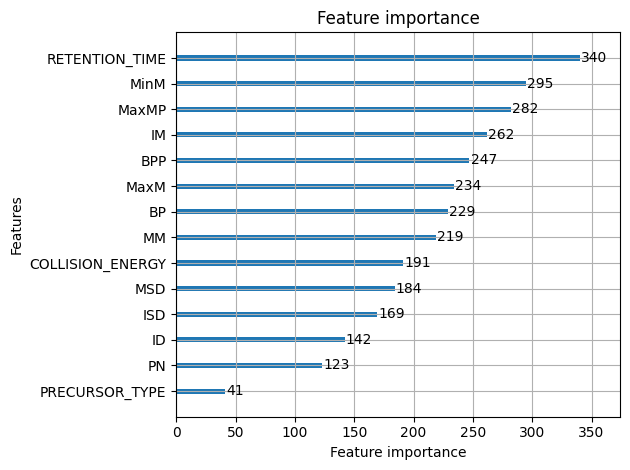

In [10]:
# 使用最佳参数训练模型
best_lgb = bayes_search.best_estimator_

# ============ 训练集评估 ============
y_train_pred = best_lgb.predict(X_train)
y_train_proba = best_lgb.predict_proba(X_train)[:, 1]

train_metrics = {
    'AUC': roc_auc_score(y_train, y_train_proba),
    'Accuracy': accuracy_score(y_train, y_train_pred),
    'Balanced Accuracy': balanced_accuracy_score(y_train, y_train_pred),
    'Precision': precision_score(y_train, y_train_pred),
    'Recall': recall_score(y_train, y_train_pred),
    'F1': f1_score(y_train, y_train_pred)
}

tn, fp, fn, tp = confusion_matrix(y_train, y_train_pred).ravel()
train_metrics['Specificity'] = tn / (tn + fp)

# ============ 测试集评估 ============
y_test_pred = best_lgb.predict(X_test)
y_test_proba = best_lgb.predict_proba(X_test)[:, 1]

test_metrics = {
    'AUC': roc_auc_score(y_test, y_test_proba),
    'Accuracy': accuracy_score(y_test, y_test_pred),
    'Balanced Accuracy': balanced_accuracy_score(y_test, y_test_pred),
    'Precision': precision_score(y_test, y_test_pred),
    'Recall': recall_score(y_test, y_test_pred),
    'F1': f1_score(y_test, y_test_pred)
}

tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
test_metrics['Specificity'] = tn / (tn + fp)

print()
print("=== 训练集性能 ===")
for metric, value in train_metrics.items():
    print(f"{metric:<18}: {value:.4f}")

print()
print("=== 测试集性能 ===")
for metric, value in test_metrics.items():
    print(f"{metric:<18}: {value:.4f}")

print()
print("测试集混淆矩阵:")
print(confusion_matrix(y_test, y_test_pred))

lgb.plot_importance(best_lgb, max_num_features=20)
plt.tight_layout()
plt.show()
    
